#  CHURN ANALYSIS


## Churn Definition

In this project, a customer is considered churned if they have not made any purchase during the last 90 days from the most recent transaction date available in the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

retail = pd.read_excel(
    "../data/online_retail_II.xlsx"
)

retail["InvoiceDate"] = pd.to_datetime(
    retail["InvoiceDate"]
)

retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [2]:
retail.shape
retail.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [3]:
# Total Amount

retail["TotalAmount"] = retail["Quantity"] * retail["Price"]

# Snapshot Date

snapshot_date = retail["InvoiceDate"].max() + pd.Timedelta(days=1)

# RFM Table

rfm = retail.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,67,15,-64.68
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,4,2646.99
12351.0,11,1,300.93


In [4]:
# Churn Definition

rfm["Churn"] = (
    rfm["Recency"] > 90
).astype(int)

rfm.head()

,Recency,Frequency,Monetary,Churn
Customer ID,,,,
12346.0,67,15,-64.68,0
12347.0,3,2,1323.32,0
12348.0,74,1,222.16,0
12349.0,43,4,2646.99,0
12351.0,11,1,300.93,0


In [5]:
rfm["Churn"].value_counts()

Churn
0    2925
1    1458
Name: count, dtype: int64

## Churn Distribution Analysis

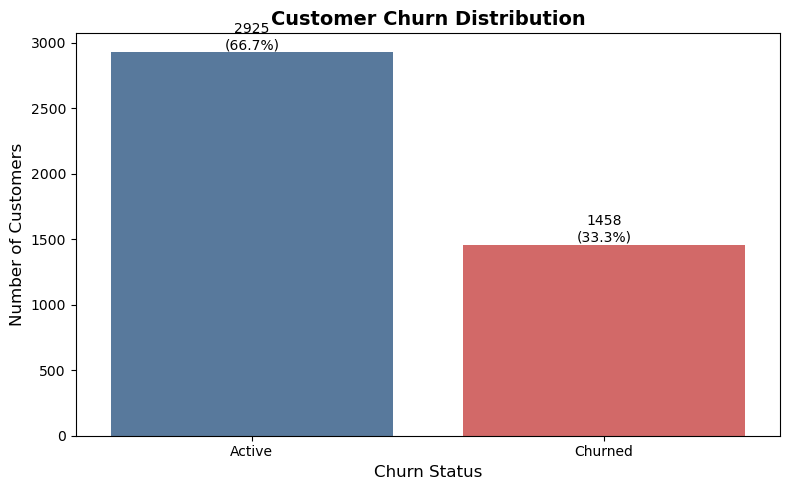

In [6]:
# Churn Distribution Analysis

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=rfm,
    x="Churn",
    hue="Churn",
    palette=["#4C78A8", "#E45756"],
    legend=False
)

plt.title(
    "Customer Churn Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Churn Status", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.xticks([0,1], ["Active","Churned"])

total = len(rfm)

for p in ax.patches:
    count = int(p.get_height())
    percentage = (count / total) * 100

    ax.annotate(
        f"{count}\n({percentage:.1f}%)",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

## Feature Selection for Churn Prediction

In [7]:
features = rfm[[
    "Recency",
    "Frequency",
    "Monetary"
]]

target = rfm["Churn"]

print("Feature Shape:", features.shape)
print("Target Shape:", target.shape)

features.head()

Feature Shape: (4383, 3)
Target Shape: (4383,)


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,67,15,-64.68
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,4,2646.99
12351.0,11,1,300.93


# Findings

- A churn target variable was created using a 90-day inactivity threshold.
- Out of 4,383 customers, 1,458 were classified as churned.
- Approximately 33.3% of customers showed churn behavior.
- Around 66.7% of customers remained active.
- The churn distribution indicates a significant portion of customers have stopped purchasing, making churn prediction a valuable business objective.

# Conclusion

A churn analysis framework was established by defining churn based on customer inactivity. The resulting target variable identified both active and churned customers, providing a foundation for predictive modeling. These results will be used in the next phase to train machine learning models for customer churn prediction.

# Churn Model Training

## Preparing Data for Modeling

In [8]:
# Features (Recency removed to avoid data leakage)

X = rfm[["Frequency", "Monetary"]]

# Target Variable
y = rfm["Churn"]

print("Features Used:")
print(X.columns.tolist())

print("\nTarget Variable:")
print(y.name)

#Features and Target



X.head()

Features Used:
['Frequency', 'Monetary']

Target Variable:
Churn


,Frequency,Monetary
Customer ID,,
12346.0,15,-64.68
12347.0,2,1323.32
12348.0,1,222.16
12349.0,4,2646.99
12351.0,1,300.93


In [9]:
#Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 3506
Testing Samples  : 877


## Logistic Regression Model

In [10]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

In [11]:
from sklearn.metrics import accuracy_score

log_accuracy = accuracy_score(y_test, log_pred)

print("Logistic Regression Accuracy:", round(log_accuracy,4))

Logistic Regression Accuracy: 0.7275


## Random Forest Model

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [13]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy,4))

Random Forest Accuracy: 0.6648


## Hyperparameter Tuning

In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators":[100,200],
    "max_depth":[5,10,None],
    "min_samples_split":[2,5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train,y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}


In [15]:
best_rf = grid_search.best_estimator_

best_pred = best_rf.predict(X_test)

best_accuracy = accuracy_score(y_test,best_pred)

print("Tuned Random Forest Accuracy:", round(best_accuracy,4))

Tuned Random Forest Accuracy: 0.7229


## Model Comparison

In [16]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy":[
        log_accuracy,
        rf_accuracy,
        best_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.727480
1,Random Forest,0.664766
2,Tuned Random Forest,0.722919


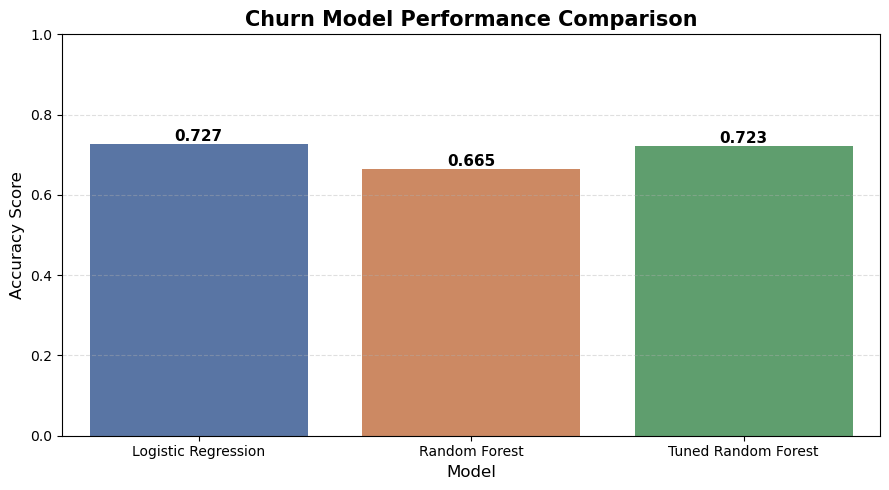

In [17]:
plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette=["#4C72B0", "#DD8452", "#55A868"],
    legend=False
)
plt.title(
    "Churn Model Performance Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Model", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)

# value labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.3f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.ylim(0, 1)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## Findings

- Logistic Regression achieved the highest accuracy of 72.75%.
- Hyperparameter tuning improved Random Forest performance from 66.48% to 72.29%.
- Both models showed comparable predictive capability for churn classification.
- Logistic Regression was selected as the preferred baseline model due to its slightly better performance and interpretability.

# MODEL EVALUATION

## Evaluating Churn Prediction Models

In [18]:
# Import Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [22]:
# Logistic Regression Evaluation

log_accuracy = accuracy_score(y_test, log_pred)

log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)

log_auc = roc_auc_score(
    y_test,
    log_model.predict_proba(X_test)[:,1]
)

print("Accuracy :", round(log_accuracy,4))
print("Precision:", round(log_precision,4))
print("Recall   :", round(log_recall,4))
print("F1 Score :", round(log_f1,4))
print("ROC-AUC  :", round(log_auc,4))

Accuracy : 0.7275
Precision: 0.6091
Recall   : 0.5068
F1 Score : 0.5533
ROC-AUC  : 0.7696


In [23]:
#Tuned Random Forest Evaluation

rf_pred = best_rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(
    y_test,
    best_rf.predict_proba(X_test)[:,1]
)

print("Accuracy :", round(rf_accuracy,4))
print("Precision:", round(rf_precision,4))
print("Recall   :", round(rf_recall,4))
print("F1 Score :", round(rf_f1,4))
print("ROC-AUC  :", round(rf_auc,4))

Accuracy : 0.7229
Precision: 0.5866
Recall   : 0.5685
F1 Score : 0.5774
ROC-AUC  : 0.7694


In [25]:
#Comparison Table
evaluation = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Tuned Random Forest"
    ],
    "Accuracy":[log_accuracy, rf_accuracy],
    "Precision":[log_precision, rf_precision],
    "Recall":[log_recall, rf_recall],
    "F1 Score":[log_f1, rf_f1],
    "ROC-AUC":[log_auc, rf_auc]
})

evaluation.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7275,0.6091,0.5068,0.5533,0.7696
1,Tuned Random Forest,0.7229,0.5866,0.5685,0.5774,0.7694


<Figure size 1000x600 with 0 Axes>

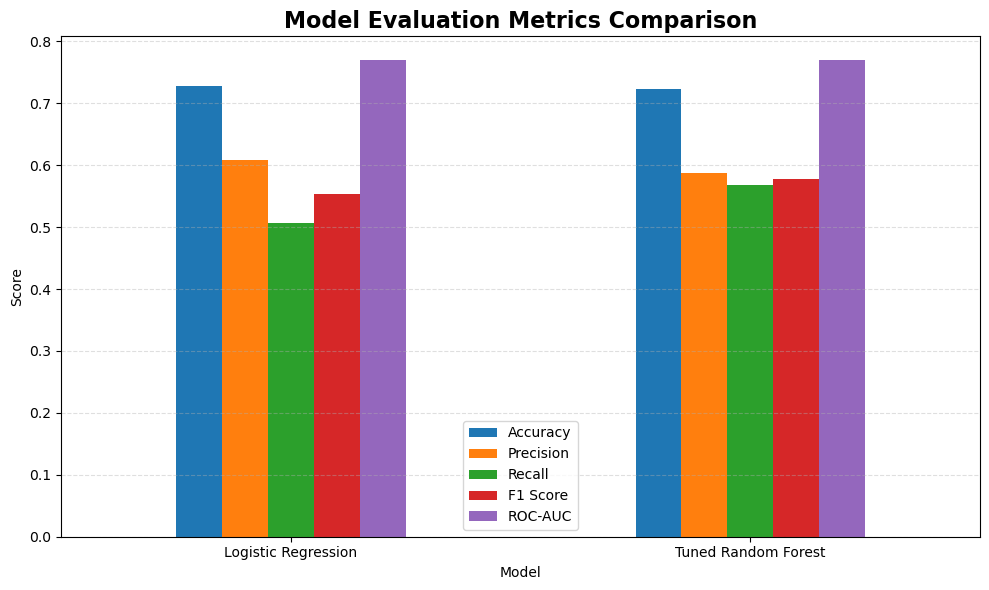

In [26]:
# Metrics Visualization
plt.figure(figsize=(10,6))

evaluation.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Model Evaluation Metrics Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

# Confusion Matrix

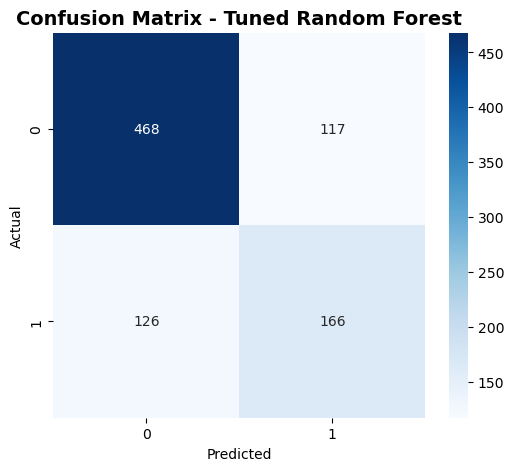

In [27]:
plt.figure(figsize=(6,5))

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix - Tuned Random Forest",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Feature Importance

In [28]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,Monetary,0.60098
0,Frequency,0.39902


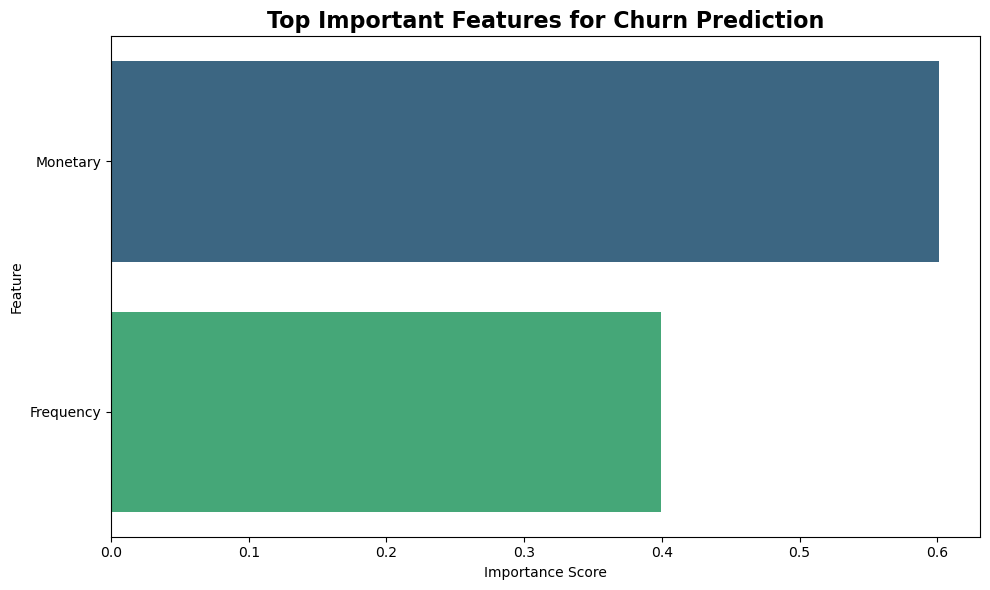

In [30]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title(
    "Top Important Features for Churn Prediction",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Findings

- Logistic Regression and Random Forest models were evaluated using multiple performance metrics.
- Accuracy alone was not considered sufficient due to class imbalance.
- Precision, Recall and F1-Score were used to assess classification performance.
- ROC-AUC was used to evaluate discrimination capability.
- Feature importance analysis identified the most influential variables affecting churn.
- The best-performing model will be used in the Streamlit dashboard for churn prediction.
- Recency was excluded from model training to prevent target leakage, as churn labels were derived using customer recency.